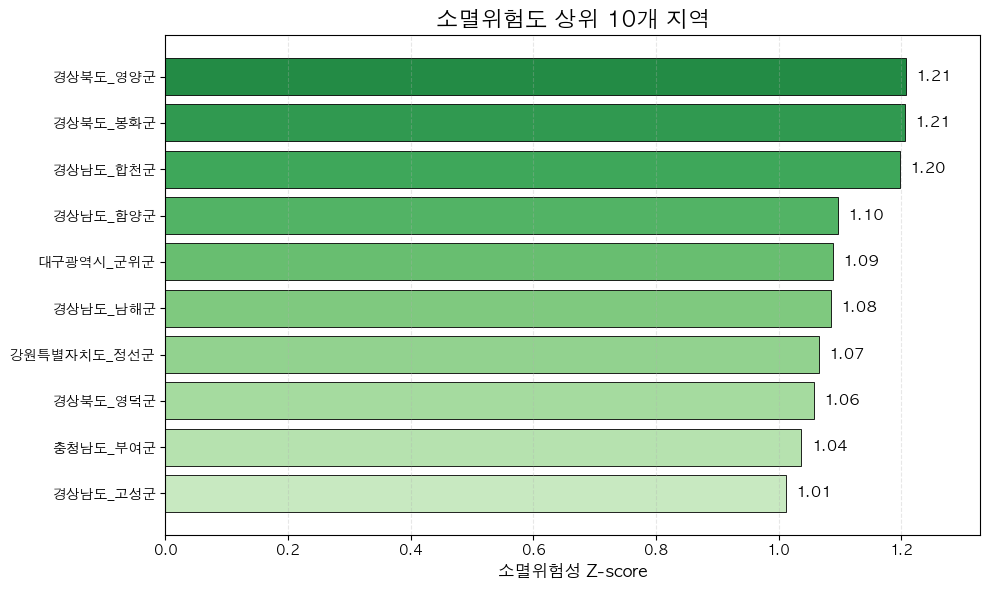

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel("data/lastRank.xlsx")

top10 = df.sort_values("소멸위험성_zscore", ascending=False).head(10)

colors = plt.cm.Greens_r(np.linspace(0.25, 0.75, len(top10)))

plt.figure(figsize=(10,6))

bars = plt.barh(
    top10["지역명"],
    top10["소멸위험성_zscore"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

plt.gca().invert_yaxis()

plt.xlabel("소멸위험성 Z-score", fontsize=12)
plt.title("소멸위험도 상위 10개 지역", fontsize=16, fontweight="bold")

plt.xlim(0, top10["소멸위험성_zscore"].max() + 0.12)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.015,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

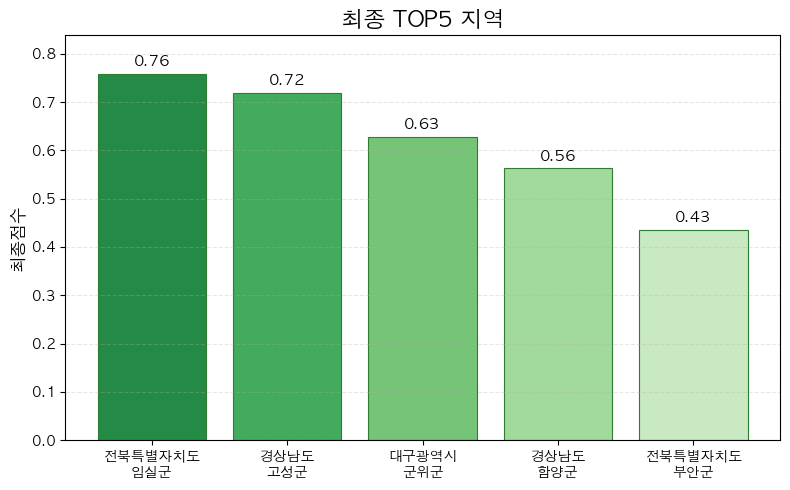

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'      
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel("data/lastRank.xlsx")

top5 = df.sort_values("최종순위").head(5)
top5["지역명"] = top5["지역명"].str.replace("_", "\n")

colors = plt.cm.Greens_r(np.linspace(0.25, 0.75, 5))

plt.figure(figsize=(8, 5))

bars = plt.bar(
    top5["지역명"],
    top5["최종점수"],
    color=colors,
    edgecolor="#2E7D32",
    linewidth=0.8
)

plt.title("최종 TOP5 지역", fontsize=16, fontweight="bold")
plt.ylabel("최종점수", fontsize=12)

plt.ylim(0, top5["최종점수"].max() + 0.08)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.01,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

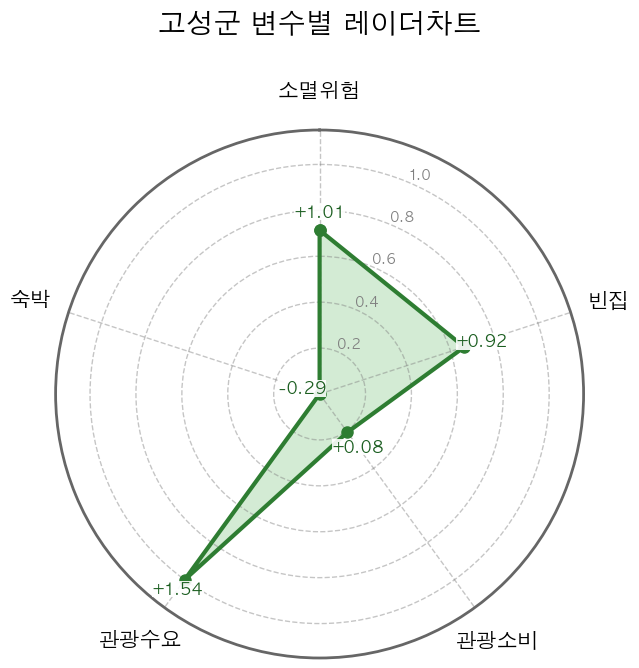

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# 한글 설정
# ==========================
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# ==========================
# 데이터 읽기
# ==========================
df = pd.read_excel("data/lastRank.xlsx")

row = df[df["지역명"] == "경상남도_고성군"].iloc[0]

# ==========================
# 레이더 순서
# 소멸위험 → 빈집 → 관광소비 → 관광수요 → 숙박
# ==========================

labels = [
    "소멸위험",
    "빈집",
    "관광소비",
    "관광수요",
    "숙박"
]

real_values = np.array([
    row["소멸위험성_zscore"],
    row["빈집_zscore"],
    row["관광소비_zscore"],
    row["관광수요_zscore"],
    row["숙박공급압박_zscore"]
])

# ==========================
# 0~1 정규화
# ==========================

values = (real_values-real_values.min())/(real_values.max()-real_values.min())

angles = np.linspace(0,2*np.pi,len(labels),endpoint=False)

angles = np.concatenate([angles,[angles[0]]])
values = np.concatenate([values,[values[0]]])

fig = plt.figure(figsize=(8,8))

ax = fig.add_axes([0.17, 0.23, 0.66, 0.66], polar=True)

# 위에서 시작
ax.set_theta_offset(np.pi/2)

# 시계방향
ax.set_theta_direction(-1)

# ==========================
# 레이더
# ==========================

ax.plot(
    angles,
    values,
    color="#2E7D32",
    linewidth=3,
    marker="o",
    markersize=8
)

ax.fill(
    angles,
    values,
    color="#81C784",
    alpha=0.35
)

# ==========================
# 축 이름
# ==========================

ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    labels,
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(axis="x",pad=18)

# ==========================
# 눈금
# ==========================

ax.set_ylim(0,1.15)

ax.set_yticks([0.2,0.4,0.6,0.8,1.0])

ax.set_yticklabels(
    ["0.2","0.4","0.6","0.8","1.0"],
    fontsize=10,
    color="gray"
)

# ==========================
# 꼭짓점 값 표시
# ==========================

offsets = [0.08,0.08,0.08,0.08,0.08]

for angle,value,score,off in zip(
    angles[:-1],
    values[:-1],
    real_values,
    offsets
):

    ax.text(
        angle,
        min(value+off,1.05),
        f"{score:+.2f}",
        fontsize=12,
        fontweight="bold",
        color="#1B5E20",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9,
            pad=0.2
        )
    )

# ==========================
# 격자
# ==========================

ax.grid(
    linestyle="--",
    linewidth=1,
    alpha=0.45,
    color="gray"
)

# ==========================
# 바깥 원
# ==========================

ax.spines["polar"].set_linewidth(2)

ax.spines["polar"].set_color("#666666")

# ==========================
# 제목
# ==========================

plt.title(
    "고성군 변수별 레이더차트",
    fontsize=20,
    fontweight="bold",
    pad=35
)

plt.show()